# Введение

**Цель:** Анализ лояльности пользователей Яндекс Афиши

**Задачи:**
1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.

## Данные

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

## Структура проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.

In [1]:
try:
    !pip install sqlalchemy
    print("✓ sqlalchemy установлен")
except Exception as e:
    print(f"✗ Ошибка установки sqlalchemy: {e}")

try:
    !pip install psycopg2
    print("✓ psycopg2 установлен")
except Exception as e:
    print(f"✗ Ошибка установки psycopg2: {e}")

try:
    !pip install psycopg2-binary
    print("✓ psycopg2-binary установлен")
except Exception as e:
    print(f"✗ Ошибка установки psycopg2-binary: {e}")
    
!pip install phik

✓ sqlalchemy установлен
  Using cached psycopg2-2.9.12.tar.gz (379 kB)
    ERROR: Command errored out with exit status 1:
     command: /opt/conda/bin/python3.9 -c 'import io, os, sys, setuptools, tokenize; sys.argv[0] = '"'"'/tmp/pip-install-pp654gno/psycopg2_2bd777df5b374df6a0e5c49c731c6428/setup.py'"'"'; __file__='"'"'/tmp/pip-install-pp654gno/psycopg2_2bd777df5b374df6a0e5c49c731c6428/setup.py'"'"';f = getattr(tokenize, '"'"'open'"'"', open)(__file__) if os.path.exists(__file__) else io.StringIO('"'"'from setuptools import setup; setup()'"'"');code = f.read().replace('"'"'\r\n'"'"', '"'"'\n'"'"');f.close();exec(compile(code, __file__, '"'"'exec'"'"'))' egg_info --egg-base /tmp/pip-pip-egg-info-njweos6a
         cwd: /tmp/pip-install-pp654gno/psycopg2_2bd777df5b374df6a0e5c49c731c6428/
    Complete output (23 lines):
    running egg_info
    creating /tmp/pip-pip-egg-info-njweos6a/psycopg2.egg-info
    writing /tmp/pip-pip-egg-info-njweos6a/psycopg2.egg-info/PKG-INFO
    writing depen

In [ ]:
import os
from dotenv import load_dotenv
import psycopg2
import pandas as pd

from sqlalchemy import create_engine
from sqlalchemy import create_engine, text

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
from phik import phik_matrix

In [ ]:
load_dotenv()

db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PWD'),
    'host': os.getenv('DB_HOST'),
    'port': os.getenv('DB_PORT'),
    'db': os.getenv('DB_NAME')
}

In [ ]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [5]:
engine = create_engine(connection_string)

# Этапы выполнения проекта

## Загрузка данных

In [6]:
## Сохранение отсортированных данных в датафрейм

query = '''
SELECT
  p.user_id,
  p.device_type_canonical,
  p.order_id,
  p.created_dt_msk as order_dt,
  p.created_ts_msk as order_ts,
  p.currency_code,
  p.revenue,
  p.tickets_count,
  EXTRACT(DAY FROM created_dt_msk - LAG(created_dt_msk) OVER (PARTITION BY user_id ORDER BY created_dt_msk)) AS days_since_prev,
  e.event_id,
  e.event_name_code as event_name,
  e.event_type_main,
  p.service_name,
  r.region_name,
  c.city_name
FROM
	afisha.events e
LEFT JOIN
	afisha.purchases p USING (event_id)
LEFT JOIN
	afisha.city c USING (city_id)
LEFT JOIN
	afisha.regions r USING (region_id)
WHERE
	p.device_type_canonical IN ('mobile', 'desktop')
	AND p.user_id IS NOT NULL
	AND event_type_main !='фильм'
ORDER BY
	p.user_id ASC,
	p.created_dt_msk ASC
'''
df = pd.read_sql_query(query, con=engine)
print (df)

                user_id device_type_canonical  order_id   order_dt  \
0       0002849b70a3ce2                mobile   4359165 2024-08-20   
1       0005ca5e93f2cf4                mobile   7965605 2024-07-23   
2       0005ca5e93f2cf4                mobile   7292370 2024-10-06   
3       000898990054619                mobile   1139875 2024-07-13   
4       000898990054619                mobile    972400 2024-10-04   
...                 ...                   ...       ...        ...   
290606  fffcd3dde79eb2c                mobile    368591 2024-10-27   
290607  fffcd3dde79eb2c                mobile    368562 2024-10-27   
290608  fffcd3dde79eb2c               desktop   8473772 2024-10-30   
290609  fffeeb3c120cf0b               desktop   5526067 2024-09-24   
290610  ffff00725179321                mobile    813654 2024-09-25   

                  order_ts currency_code  revenue  tickets_count  \
0      2024-08-20 16:08:03           rub  1521.94              4   
1      2024-07-23 18:36

## Предобработка данных

In [7]:
display (df.head(), df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


None

- **Пропуски**: пропуски есть только в ``days_since_prev`` (=пользователь имел только 1 заказ).
- **Типы данных**: можно оптимизировать типы.
- **Названия столбцов**: ок, все однотипное.
- **Дубликаты**: в списке заказов могут быть дубликаты, необходима проверка 
- **Качество данных**
    - Категориальные: 
        - device_type_canonical
        - currency_code
        - event_type_main
        - service_name
        - region_name
        - city_name
    - Кол-венные: 
        - revenue
        - tickets_count
        - days_since_prev
У категориальных значений могут быть различия в регистре, формате записи или опечатки, необходим доп. анализ.
У кол-венных необходимо убедиться в отсутствии выбросов и некорректных значений (например, отрицательная стоимость). 

**Вывод по выгрузке**: данные загружены полностью, без критических потерь. Единственный нюанс — это пропуски в колонке days_since_prev, но это ожидаемо для первых покупок пользователей (там нечего вычислять). Дополнительно нужна проверка качества данных.

### Конвертация валют
Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Надо привести выручку к единой валюте — российскому рублю.

Источник с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`.
Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

In [8]:
kzt2rub = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

#Проверка выгрузки
display (kzt2rub.head())
display (kzt2rub.info()) 

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


None

Колонка ``data`` типа ``object``, необходимо проверить, точно ли она ``data``, иначе не сможем сравнить дату ``df`` и ``kzt2rub``

In [9]:
print(type(kzt2rub['data'].iloc[0]))

<class 'str'>


In [10]:
kzt2rub['data'] = pd.to_datetime(kzt2rub['data']) # data data

In [11]:
print(type(kzt2rub['data'].iloc[0]))

<class 'pandas._libs.tslibs.timestamps.Timestamp'>


In [12]:
# джоиним таблицы по дате
df = df.merge(kzt2rub, left_on='order_dt', right_on='data', how='left')

# конвертация
df['revenue_rub'] = df['revenue'].where(df['currency_code'] == 'rub', df['revenue'] * df['curs'] / 100)

# чистка лишнего
df.drop(['cdx', 'curs', 'nominal', 'data'], axis=1, inplace=True)

df.head(10)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,1390.41
5,000898990054619,mobile,2613713,2024-10-23,2024-10-23 15:12:00,rub,902.74,3,19.0,500862,9cc55c15-4375-4129-9979-3129688ba1b4,концерты,Облачко,Лугоградская область,Кристалевск,902.74
6,00096d1f542ab2b,desktop,6636941,2024-08-15,2024-08-15 16:48:48,rub,917.83,4,NaN,201953,2f98d69f-4e60-4ffc-8f16-e539383526b1,театр,Край билетов,Каменевский регион,Глиногорск,917.83
7,000a55a418c128c,mobile,4657981,2024-09-29,2024-09-29 19:39:12,rub,47.78,1,NaN,265857,0d876e01-851e-458b-ba61-753e0e0c4063,театр,Лучшие билеты,Поленовский край,Дальнозолотск,47.78
8,000a55a418c128c,mobile,4657952,2024-10-15,2024-10-15 10:29:04,rub,74.84,2,16.0,271579,ddc795f8-7ef8-4eb0-b299-cb3e6ee24ba1,театр,Лучшие билеты,Поленовский край,Дальнозолотск,74.84
9,000cf0659a9f40f,mobile,6818017,2024-06-20,2024-06-20 10:35:26,rub,1421.91,4,NaN,516728,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерты,Лови билет!,Широковская область,Радужнополье,1421.91


Теперь можно объединить таблицы и конвертировать валюту

Результаты преобразования в новом столбце `revenue_rub`.

### Преобразование типов данных

In [13]:
display (df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

None

In [14]:
df['order_id'] = pd.to_numeric(df['order_id'], downcast='integer')
df['revenue'] = pd.to_numeric(df['revenue'], downcast='float')
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')
df['days_since_prev'] = pd.to_numeric(df['days_since_prev'], downcast='float')
df['event_id'] = pd.to_numeric(df['event_id'], downcast='integer')

In [15]:
display (df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float32       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float32       
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

None

Изменения в типах:
- ``order_id``: int64 -> int32
- ``revenue``: float64 -> float16
- ``tickets_count``: float64 -> float32
- ``days_since_prev``: int64 -> int32
- ``event_id``: int64 -> int32

Итоговый файл стал весить в 2 раза меньше

### Анализ явных и неявных дубликатов
#### Анализ явных дубликатов

In [16]:
df['device_type_canonical'].value_counts()

mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64

Явных дубликатов нет

In [17]:
df['currency_code'].value_counts()

rub    285542
kzt      5069
Name: currency_code, dtype: int64

Явных дубликатов нет

In [18]:
df['event_type_main'].value_counts()

концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: event_type_main, dtype: int64

Явных дубликатов нет и разных регистров нет

In [19]:
df['service_name'].value_counts()

Билеты без проблем        63519
Лови билет!               41124
Билеты в руки             40343
Мой билет                 34839
Облачко                   26642
Лучшие билеты             17774
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Мир касс                   2167
Быстробилет                2003
Выступления.ру             1616
Восьмёрка                  1118
Crazy ticket!               790
Росбилет                    539
Шоу начинается!             499
Быстрый кассир              381
Радио ticket                376
Телебилет                   321
КарандашРУ                  133
Реестр                      125
Билет по телефону            85
Вперёд!                      80
Дырокол                      74
Кино билет                   67
Цвет и б

Явных дубликатов нет и разных регистров нет

In [20]:
df['region_name'].value_counts()

Каменевский регион          91058
Североярская область        44049
Широковская область         16457
Медовская область           13901
Озернинский край            10476
                            ...  
Лесноярский край               19
Крутоводский регион            18
Верхозёрский край              11
Сосноводолинская область       10
Теплоозёрский округ             7
Name: region_name, Length: 81, dtype: int64

Возможны проблемы с разным регистром.

In [21]:
df['region_name'] = df['region_name'].str.lower()
df['region_name'].value_counts()

каменевский регион          91058
североярская область        44049
широковская область         16457
медовская область           13901
озернинский край            10476
                            ...  
лесноярский край               19
крутоводский регион            18
верхозёрский край              11
сосноводолинская область       10
теплоозёрский округ             7
Name: region_name, Length: 81, dtype: int64

Явных дубликатов нет и разных регистров нет

In [22]:
df['city_name'].value_counts()

Глиногорск      89446
Озёрск          43910
Радужсвет       13711
Радужнополье     8741
Верховино        6579
                ...  
Дальнозелен         1
Ягодинска           1
Озёроярск           1
Байсары             1
Травино             1
Name: city_name, Length: 352, dtype: int64

Возможны проблемы с разным регистром.

In [23]:
df['city_name'] = df['city_name'].str.lower()
df['city_name'].value_counts()

глиногорск       89446
озёрск           43910
радужсвет        13711
радужнополье      8741
верховино         6579
                 ...  
мироград             1
яблоновец            1
поляноречинск        1
карасуй              1
радужовинск          1
Name: city_name, Length: 352, dtype: int64

Явных дубликатов нет и разных регистров нет

Не найдено категорий, которые обозначают пропуски или отсутствие данных

In [24]:
# Проверка явных дублей
df_no_duplicates = df.drop_duplicates()
df_no_duplicates.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float32       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float32       
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Явных дубликатов нет

#### Анализ неявных дубликатов

In [25]:
# Определяем дубликаты по user_id и order_id
duplicated_rows = df.duplicated(subset=['user_id', 'order_id'])
duplicated_rows.sum()

0

In [26]:
# Определяем дубликаты по user_id, event_id, order_ts
duplicated_rows = df.duplicated(subset=['user_id', 'event_id', 'order_ts'])
duplicated_rows.sum()

120

In [27]:
# Анализ дубликатов
duplicates = df[df.duplicated(subset=['user_id', 'event_id', 'order_ts'], keep=False)]

display(duplicates.head(10))

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
4355,02ea4583333f064,mobile,1158638,2024-08-23,2024-08-23 22:46:05,rub,89.610001,3,0.0,540072,092b4a33-3898-4c17-b89c-6fbaa5dc9386,другое,Билеты в руки,зеленоградский округ,шаныртау,89.61
4359,02ea4583333f064,mobile,1158696,2024-08-23,2024-08-23 22:46:05,rub,59.740002,2,0.0,540072,092b4a33-3898-4c17-b89c-6fbaa5dc9386,другое,Билеты в руки,зеленоградский округ,шаныртау,59.74
11758,06eb7897f65b433,mobile,1123867,2024-08-13,2024-08-13 16:31:07,rub,69.820000,1,0.0,183706,69796237-909b-42a7-bfb5-c1b8574c4c76,театр,Билеты в руки,светополянский округ,глиноград,69.82
11761,06eb7897f65b433,mobile,1123983,2024-08-13,2024-08-13 16:31:07,rub,69.820000,1,0.0,183706,69796237-909b-42a7-bfb5-c1b8574c4c76,театр,Билеты в руки,светополянский округ,глиноград,69.82
12677,08199117318954f,desktop,5592970,2024-07-31,2024-07-31 11:52:06,rub,0.000000,3,0.0,553623,8aa79719-8122-4b50-ae2a-fa484d034c5c,другое,Билеты без проблем,каменевский регион,глиногорск,0.00
12679,08199117318954f,mobile,5593202,2024-07-31,2024-07-31 11:52:06,rub,0.000000,3,0.0,553623,8aa79719-8122-4b50-ae2a-fa484d034c5c,другое,Билеты без проблем,каменевский регион,глиногорск,0.00
14017,0ae42a8c1d07049,mobile,2533905,2024-09-02,2024-09-02 13:14:47,rub,95.169998,4,8.0,561445,136cecf8-c47b-4529-90ec-332684696a5a,спорт,Билеты без проблем,чистогорская область,леснойск,95.17
14020,0ae42a8c1d07049,mobile,2534659,2024-09-02,2024-09-02 13:14:47,rub,47.590000,2,0.0,561445,136cecf8-c47b-4529-90ec-332684696a5a,спорт,Билеты без проблем,чистогорская область,леснойск,47.59
16123,0beb8fc0c0a9ce1,desktop,144305,2024-07-05,2024-07-05 11:18:59,rub,351.970001,4,0.0,496111,e422332a-ed25-4053-a3a8-f0a89fffbc74,театр,Прачечная,каменевский регион,глиногорск,351.97
16187,0beb8fc0c0a9ce1,mobile,1294329,2024-07-05,2024-07-05 11:18:59,rub,87.989998,1,0.0,496111,e422332a-ed25-4053-a3a8-f0a89fffbc74,театр,Прачечная,каменевский регион,глиногорск,87.99


Типы дублей

1. Сплит одного заказа по билетам


| Признак | Описание |
|---------|----------|
| **Пример** | `user_id = 4355` и `4359` |
| **Что совпадает** | `user_id`, `event_id`, `order_dt`, `order_ts`, устройство, место проведения |
| **Что отличается** | `order_id`, `revenue`, `tickets_count` |
| **Природа** | Один логический заказ разбит на несколько строк ->  это не дубли, а детализация |

---

2. Дубли из-за разных устройств (desktop / mobile)
| Признак | Описание |
|---------|----------|
| **Пример** | `user_id = 12677` и `12679` |
| **Что совпадает** | `user_id`, `event_id`, `order_dt`, `order_ts`, `revenue`, `tickets_count` |
| **Что отличается** | `order_id`, `device_type_canonical` |
| **Природа** | Один заказ записан дважды — с десктопа и с мобильного устройства. Возможные причины: <br> - пользователь начал покупку на одном устройстве, завершил на другом; <br> - технический дубль из-за трекинга; <br> - баг при передаче данных между системами. |

---

3. Полные дубли (кроме order_id)
| Признак | Описание |
|---------|----------|
| **Пример** | `user_id = 11758` и `11761` |
| **Что совпадает** | **Все поля**, кроме `order_id` |
| **Что отличается** | только `order_id` |
| **Природа** | Наиболее вероятные причины: <br> - повторная отправка запроса при сетевом сбое; <br> - дублирование на этапе загрузки данных; <br> - один заказ, но система по ошибке создала два `order_id`. |

---

4. Разные заказы в рамках одной сессии
| Признак | Описание |
|---------|----------|
| **Пример** | `user_id = 0beb8fc0c0a9ce1` |
| **Что совпадает** | `user_id`, `event_id`, `order_dt`, `order_ts` |
| **Что отличается** | `order_id`, `device_type`, `revenue`, `tickets_count` |
| **Природа** | Пользователь купил несколько билетов двумя разными заказами в одно и то же время (например, 4 билета + 1 билет). Это **реальные разные заказы**, а не дубли. |

---
Вывод

> Большая часть «дублей» в данных — это **не ошибка**, а **отражение бизнес-логики** (сплит по билетам, мультиустройственность, несколько заказов за раз).  
> Однако присутствуют и **технические дубли** (полное совпадение всех полей, кроме `order_id`), которые требуют очистки перед любым агрегирующим анализом.

In [28]:
#Удаление дублей

df_len = len(df)
print(f'Строк до удаления {df_len}')

df = df.drop_duplicates(subset=['user_id', 'event_id', 'order_ts', 'revenue', 'tickets_count', 'currency_code'], keep='first')
print(f'Строк после удаления {len(df)}. Удалено строк: {df_len - len(df)}')

Строк до удаления 290611
Строк после удаления 290567. Удалено строк: 44


### Очистка данных

In [29]:
df.describe(percentiles=[0.25, 0.5, 0.74, 0.99])

,order_id,revenue,tickets_count,days_since_prev,event_id,revenue_rub
count,2.905670e+05,290567.000000,290567.000000,268634.000000,290567.000000,290567.000000
mean,4.326194e+06,625.610229,2.754315,3.222909,438014.575299,555.592389
std,2.497557e+06,1227.760254,1.170605,11.351364,147426.022667,875.533069
min,1.000000e+00,-90.760002,1.000000,0.000000,4436.000000,-90.760000
25%,2.163532e+06,116.870003,2.000000,0.000000,361718.000000,113.970000
50%,4.326337e+06,356.019989,3.000000,0.000000,498275.000000,351.140000
74%,6.400006e+06,788.900024,3.000000,1.000000,544623.000000,783.610000
99%,8.566901e+06,4003.459961,6.000000,63.000000,589623.000000,2628.421739
max,8.653108e+06,81174.539062,57.000000,148.000000,592325.000000,81174.540000


1.   tickets_count имеет в среднем 3 билета на заказ. Минимум 1 билет, максимум 57. Выбросов не замечено.
2.   revenue_rub имеет левый хвост. Минимум -90 (возможно возврат), максимум 81к. Выбросы есть, необходима чистка.  

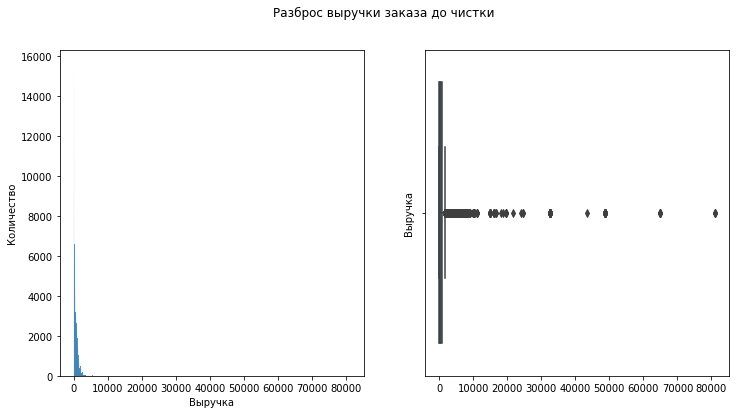

In [30]:
# Графики

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('Разброс выручки заказа до чистки')

sns.histplot(data=df, x='revenue_rub', ax=axes[0]) 
axes[0].set(xlabel='Выручка', ylabel='Количество')

sns.boxplot(data=df, x='revenue_rub', ax=axes[1])  
axes[1].set(xlabel='', ylabel='Выручка')

plt.show()

- На графике явно высокий уровень выбросов. Возможно, что какие-то ивенты были под заказ и все билеты были проданы заказчиком. Или перекупщики покупали долю мест на мероприятии. Стоит попробовать обрезать выбросные значения. 
- Есть отрицательные значения, возможно это возвраты или баг в системе, тоже необходимо почистить.

In [31]:
print ('Описательная статистика revenue_rub до выбросов')

df['revenue_rub'].describe(percentiles=[0.25, 0.5, 0.75, 0.99])

Описательная статистика revenue_rub до выбросов


count    290567.000000
mean        555.592389
std         875.533069
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
99%        2628.421739
max       81174.540000
Name: revenue_rub, dtype: float64

In [32]:
# Сохранение 99% и => 0
df_revenue_99 = (
    (df['revenue_rub'] < df['revenue_rub'].quantile(.99))
    & (df['revenue_rub'] >= 0)
)
revenue_rub_99 = df[df_revenue_99]['revenue_rub']

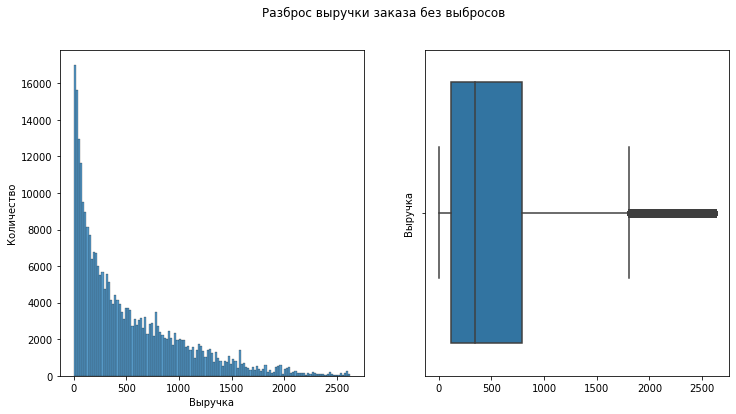

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Разброс выручки заказа без выбросов')

sns.histplot(x=revenue_rub_99, ax=axes[0]) 
axes[0].set(xlabel='Выручка', ylabel='Количество')

sns.boxplot(x=revenue_rub_99, ax=axes[1])   
axes[1].set(xlabel='', ylabel='Выручка')

plt.show()

In [34]:
revenue_rub_99.describe(percentiles=[0.25, 0.5, 0.75, 0.99])

count    287179.000000
mean        517.397227
std         509.336987
min           0.000000
25%         112.440000
50%         344.300000
75%         788.640000
99%        2131.670000
max        2627.000000
Name: revenue_rub, dtype: float64

- Минимум теперь 0
- Максимум сократился с 81174.54 до 2627
- Размах сократился от 875 до 509
- Среднее значение сократилось с 555 до 517

Данные стали более четкими, выбросы остались, но с меньшим размахом. 

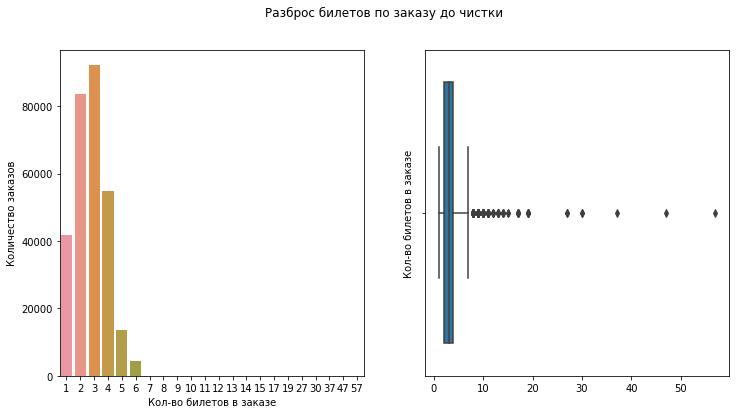

In [35]:
ticket_counts = df['tickets_count'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Разброс билетов по заказу до чистки')

sns.barplot(x=ticket_counts.index, y=ticket_counts.values, ax=axes[0])
axes[0].set(xlabel='Кол-во билетов в заказе', ylabel='Количество заказов')


sns.boxplot(x=df['tickets_count'], ax=axes[1])
axes[1].set(xlabel='', ylabel='Кол-во билетов в заказе')


plt.show()

In [36]:
print ('Описательная статистика revenue_rub до выбросов')

df['tickets_count'].describe(percentiles=[0.25, 0.5, 0.75, 0.99])

Описательная статистика revenue_rub до выбросов


count    290567.000000
mean          2.754315
std           1.170605
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
99%           6.000000
max          57.000000
Name: tickets_count, dtype: float64

Среднее значение выглядит реалистичным, но имеется множественный выброс значений. Все еще объясняется теорией ивентов под заказ или перекупом. Необходимо попробовать аналогично сокрвтить выбросы 

In [37]:
# Сохранение 99%
tickets_99 = df['tickets_count'].quantile(0.99)
ticket_counts = df[df['tickets_count'] <= tickets_99]['tickets_count'].value_counts().sort_index()

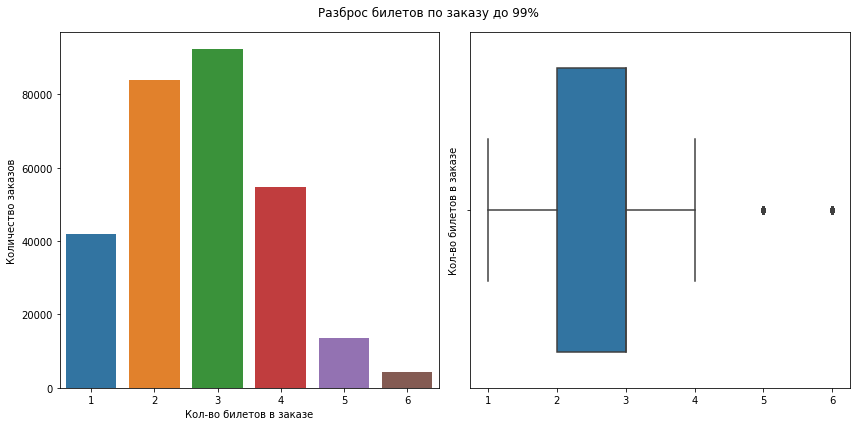

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Разброс билетов по заказу до 99%')

sns.barplot(x=ticket_counts.index, y=ticket_counts.values, ax=axes[0])
axes[0].set(xlabel='Кол-во билетов в заказе', ylabel='Количество заказов')

filtered_data = df[df['tickets_count'] <= tickets_99]
sns.boxplot(x=filtered_data['tickets_count'], ax=axes[1])
axes[1].set(xlabel='', ylabel='Кол-во билетов в заказе')

plt.tight_layout()
plt.show()

Среднее значение осталось 2-3, но выброс значений стал меньше. Чистим изначальный датасет на 99 квантиль по tickets_count и revenue_rub

In [39]:
df_filtered = df[
    (df['tickets_count'] <= df['tickets_count'].quantile(0.99)) &
    (df['revenue_rub'] <= df['revenue_rub'].quantile(0.99)) &
    (df['revenue_rub'] >= 0)
]

df_filtered.describe(percentiles=[0.25, 0.5, 0.74, 0.99])

,order_id,revenue,tickets_count,days_since_prev,event_id,revenue_rub
count,2.871810e+05,287181.000000,287181.000000,265498.000000,287181.000000,287181.000000
mean,4.327090e+06,572.972351,2.736462,3.225587,437717.423221,518.496404
std,2.497678e+06,836.409973,1.136155,11.357661,147560.025389,511.848545
min,1.000000e+00,0.000000,1.000000,0.000000,4436.000000,0.000000
25%,2.165257e+06,116.239998,2.000000,0.000000,360651.000000,112.520000
50%,4.327236e+06,348.829987,3.000000,0.000000,496940.000000,344.620000
74%,6.400916e+06,779.510010,3.000000,1.000000,544570.400000,768.360000
99%,8.567100e+06,2594.439941,6.000000,63.000000,589623.000000,2156.080000
max,8.653108e+06,13784.259766,6.000000,148.000000,592325.000000,2628.421739


**Итог:** Фильтрация по ``tickets_count`` <= 99% и 0 < ``revenue_rub``<= 99% оказалась крайне эффективной для борьбы с выбросами, особенно в целевом показателе — выручке.
Убрав 1%, снизилась волатильность (стандартное отклонение упало с 4702 до 854) и получилась более репрезентативное среднее значение, которое теперь лучше отражает типичный чек (около 575 рублей вместо завышенных 982).

# Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

## **Задача 1**. Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в **котором** был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.


In [40]:
profiles = df.pivot_table(
    index='user_id',
    values=['order_dt', 'device_type_canonical', 'region_name', 'service_name',
            'event_type_main', 'order_id', 'revenue_rub', 'tickets_count', 'days_since_prev'],
    aggfunc={
        'order_dt': ['first', 'last', 'count'],
        'device_type_canonical': 'first',
        'region_name': 'first',
        'service_name': 'first',
        'event_type_main': 'first',
        'order_id': 'count',
        'revenue_rub': 'mean',
        'tickets_count': 'mean',
        'days_since_prev': 'mean'
    }
)

profiles['is_two'] = profiles[('order_id', 'count')] >= 2
profiles['is_five'] = profiles[('order_id', 'count')] >= 5



display (profiles)

days_since_prev device_type_canonical event_type_main  \
                           mean                 first           first   
user_id                                                                 
0002849b70a3ce2             NaN                mobile           театр   
0005ca5e93f2cf4          75.000                mobile        выставки   
000898990054619          51.000                mobile          другое   
00096d1f542ab2b             NaN               desktop           театр   
000a55a418c128c          16.000                mobile           театр   
...                         ...                   ...             ...   
fff13b79bd47d7c          13.375                mobile          другое   
fff32fc9ad0f9f6          74.000               desktop         стендап   
fffcd3dde79eb2c           4.125               desktop        концерты   
fffeeb3c120cf0b             NaN               desktop         стендап   
ffff00725179321             NaN                mobile        концерты   

                order_dt                       order_id           region_name  \
                   count      first       last    count                 first   
user_id                                                                         
0002849b70a3ce2        1 2024-08-20 2024-08-20        1    каменевский регион   
0005ca5e93f2cf4        2 2024-07-23 2024-10-06        2    каменевский регион   
000898990054619        3 2024-07-13 2024-10-23        3  североярская область   
00096d1f542ab2b        1 2024-08-15 2024-08-15        1    каменевский регион   
000a55a418c128c        2 2024-09-29 2024-10-15        2      поленовский край   
...                  ...        ...        ...      ...                   ...   
fff13b79bd47d7c        9 2024-07-16 2024-10-31        9    каменевский регион   
fff32fc9ad0f9f6        2 2024-08-15 2024-10-28        2    каменевский регион   
fffcd3dde79eb2c       33 2024-06-20 2024-10-30       33    каменевский регион   
fffeeb3c120cf0b        1 2024-09-24 2024-09-24        1   широковская область   
ffff00725179321        1 2024-09-25 2024-09-25        1  малиновоярский округ   

                 revenue_rub        service_name tickets_count is_two is_five  
                        mean               first          mean                 
user_id                                                                        
0002849b70a3ce2  1521.940000        Край билетов      4.000000  False   False  
0005ca5e93f2cf4   774.010000           Мой билет      3.000000   True   False  
000898990054619   767.213333         Лови билет!      2.666667   True   False  
00096d1f542ab2b   917.830000        Край билетов      4.000000  False   False  
000a55a418c128c    61.310000       Лучшие билеты      1.500000   True   False  
...                      ...                 ...           ...    ...     ...  
fff13b79bd47d7c   688.043333           Мой билет      2.555556   True    True  
fff32fc9ad0f9f6   850.995000  Билеты без проблем      2.500000   True   False  
fffcd3dde79eb2c   557.908485  Билеты без проблем      2.787879   True    True  
fffeeb3c120cf0b   661.530000  Билеты без проблем      2.000000  False   False  
ffff00725179321   802.250000           Мой билет      2.000000  False   False  

[21933 rows x 13 columns]

## **Задача 2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [41]:
is_two = profiles['is_two'].sum()/profiles['is_two'].count()
is_five = profiles['is_five'].sum()/profiles['is_five'].count()

print(
    f'Общее число пользователей в выборке: {len(profiles)}',
     f'\nСредняя выручка с одного заказа: {profiles[("revenue_rub", "mean")].mean():.2f}' ,
    f'\nДоля пользователей, совершивших 2 и более заказа: {is_two.round(2)}%',
    f'\nДоля пользователей, совершивших 5 и более заказов:  {is_five.round(2)}%'
    )

Общее число пользователей в выборке: 21933 
Средняя выручка с одного заказа: 574.02 
Доля пользователей, совершивших 2 и более заказа: 0.62% 
Доля пользователей, совершивших 5 и более заказов:  0.29%


In [42]:
profiles[[('order_id', 'count'), ('tickets_count', 'mean'), ('order_dt', 'count')]].describe(percentiles=[0.25, 0.5, 0.75, 0.99])

,order_id,tickets_count,order_dt
,count,mean,count
count,21933.000000,21933.000000,21933.000000
mean,13.247937,2.755987,13.247937
std,122.455985,0.920725,122.455985
min,1.000000,1.000000,1.000000
25%,1.000000,2.000000,1.000000
50%,2.000000,2.764151,2.000000
75%,5.000000,3.125000,5.000000
99%,152.000000,5.000000,152.000000
max,10251.000000,12.000000,10251.000000


1. ``order_id`` - имеет большой выброс
2. ``order_dt`` - имеет большой выброс

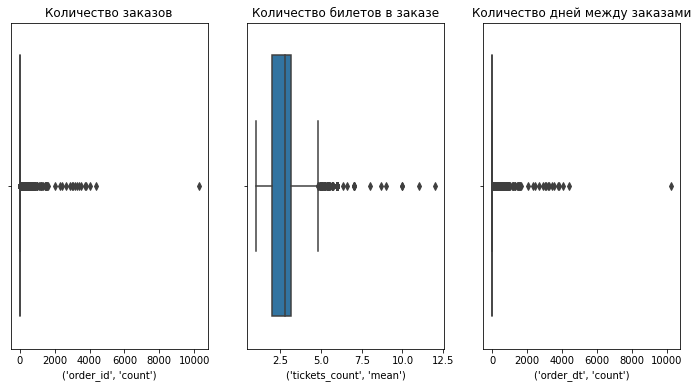

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

sns.boxplot(x=profiles[('order_id', 'count')], ax=axes[0])
axes[0].set(ylabel='', title='Количество заказов')

sns.boxplot(x=profiles[('tickets_count', 'mean')], ax=axes[1])
axes[1].set(ylabel='', title='Количество билетов в заказе')

sns.boxplot(x=profiles[('order_dt', 'count')], ax=axes[2])
axes[2].set(ylabel='', title='Количество дней между заказами')

fig.set_constrained_layout_pads(wspace=0.15)
plt.show()

In [44]:
profiles_filtered = profiles[
    (profiles[('order_id', 'count')] <= profiles[('order_id', 'count')].quantile(0.99)) &
    (profiles[('tickets_count', 'mean')] <= profiles[('tickets_count', 'mean')].quantile(0.99)) &
    (profiles[('order_dt', 'count')] <= profiles[('order_dt', 'count')].quantile(0.99))
]

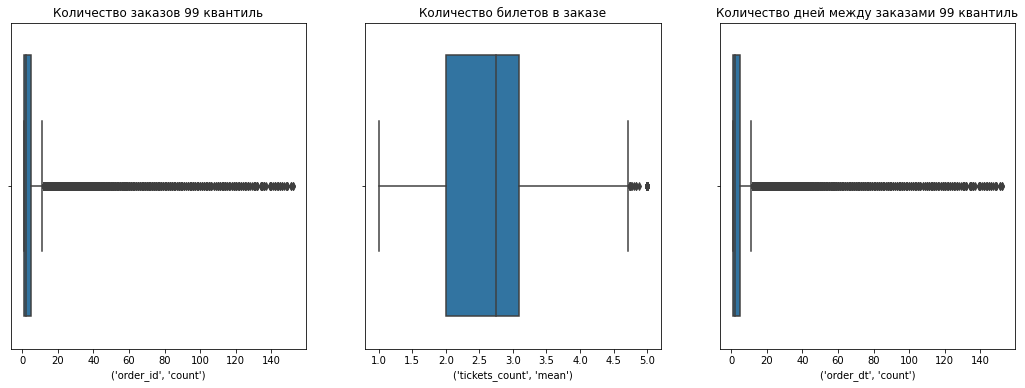

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(x=profiles_filtered[('order_id', 'count')], ax=axes[0])
axes[0].set(ylabel='', title='Количество заказов 99 квантиль')

sns.boxplot(x=profiles_filtered[('tickets_count', 'mean')], ax=axes[1])
axes[1].set(ylabel='', title='Количество билетов в заказе')

sns.boxplot(x=profiles_filtered[('order_dt', 'count')], ax=axes[2])
axes[2].set(ylabel='', title='Количество дней между заказами 99 квантиль')

fig.set_constrained_layout_pads(wspace=0.15)
plt.show()

In [46]:
profiles_filtered[[('order_id', 'count'), ('tickets_count', 'mean'), ('order_dt', 'count')]].describe(percentiles=[0.25, 0.5, 0.75, 0.99])

,order_id,tickets_count,order_dt
,count,mean,count
count,21505.000000,21505.000000,21505.000000
mean,6.566566,2.724419,6.566566
std,14.394014,0.867978,14.394014
min,1.000000,1.000000,1.000000
25%,1.000000,2.000000,1.000000
50%,2.000000,2.750000,2.000000
75%,5.000000,3.090909,5.000000
99%,80.000000,5.000000,80.000000
max,152.000000,5.000000,152.000000


Фильтрация по 99%

1. по общему числу заказов;
2. по среднему числу билетов в заказе;
3. по среднему количеству дней между покупками.

Итог:
1. Уменьшилась волатильнось
2. Не изменилось значение 75 квантиля, значит общий состав данных не изменился.

# Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



## Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

### **Задача 1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?


,"(event_type_main, first)",count,percentage
0,выставки,409,1.90
1,другое,5349,24.87
2,концерты,9557,44.44
3,спорт,788,3.66
4,стендап,1095,5.09
5,театр,4212,19.59
6,ёлки,95,0.44


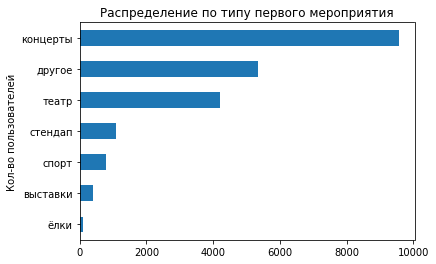

In [47]:
# Распределение по типу первого мероприятия
pivot_table = profiles_filtered.groupby(('event_type_main', 'first')).size().reset_index(name='count')
pivot_table['percentage'] = (pivot_table['count'] / pivot_table['count'].sum() * 100).round(2)
display(pivot_table)


pivot_table.sort_values(by='count', ascending=True).plot(
    kind='barh',
    title='Распределение по типу первого мероприятия',
    legend=False,
    ylabel='Тип мероприятия',
    xlabel='Кол-во пользователей',
    y='count',
    x=('event_type_main', 'first'))
plt.show()


,"(device_type_canonical, first)",count,percentage
0,desktop,3715,17.28
1,mobile,17790,82.72


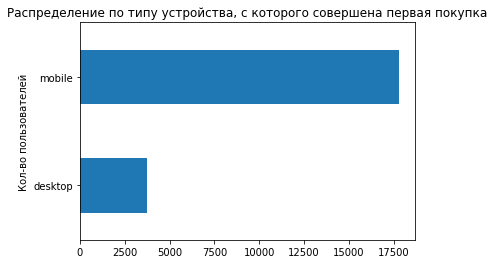

In [48]:
# Распределение по типу устройства, с которого совершена первая покупка
pivot_table = profiles_filtered.groupby(('device_type_canonical', 'first')).size().reset_index(name='count')
pivot_table['percentage'] = (pivot_table['count'] / pivot_table['count'].sum() * 100).round(2)
display(pivot_table)


pivot_table.sort_values(by='count', ascending=True).plot(
    kind='barh',
    title='Распределение по типу устройства, с которого совершена первая покупка',
    legend=False,
    ylabel='Тип устройства',
    xlabel='Кол-во пользователей',
    y='count',
    x=('device_type_canonical', 'first'))
plt.show()

,"(region_name, first)",count,percentage
0,белоярская область,19,0.09
1,берестовский округ,22,0.10
2,берёзовская область,118,0.55
3,боровлянский край,97,0.45
4,верховинская область,3,0.01
...,...,...,...
76,шанырский регион,501,2.33
77,широковская область,1213,5.64
78,яблоневская область,409,1.90
79,ягодиновская область,64,0.30


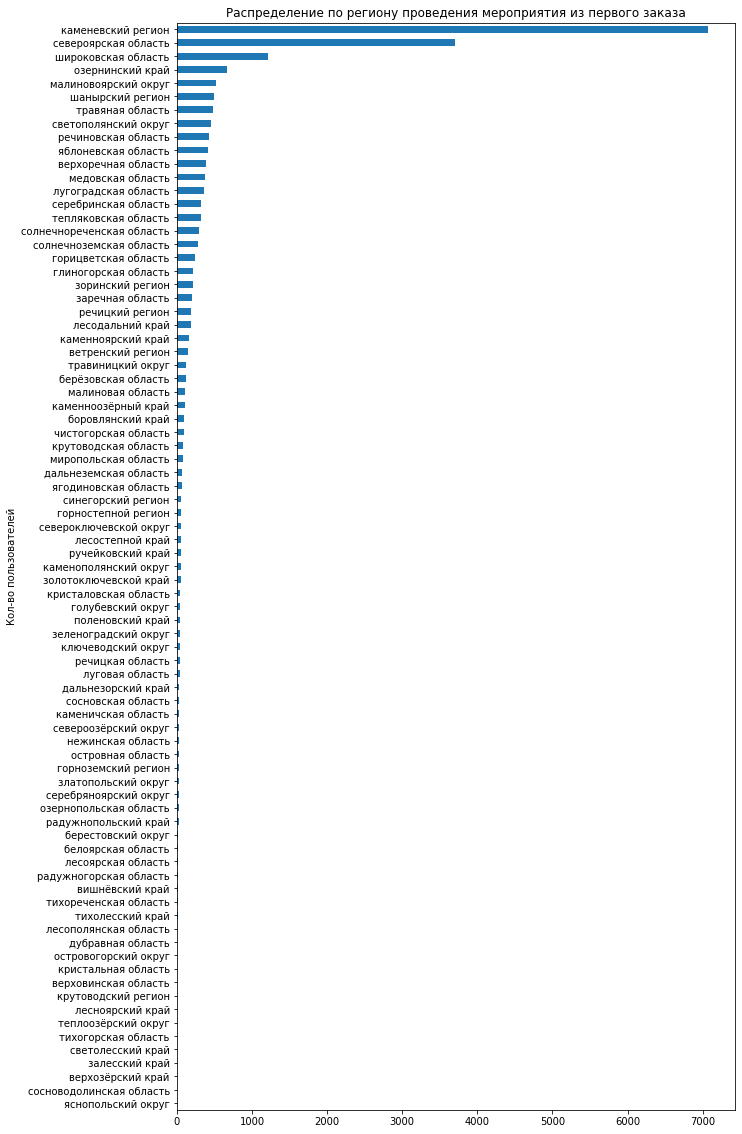

In [49]:
# Распределение по региону проведения мероприятия из первого заказа

pivot_table = profiles_filtered.groupby(('region_name', 'first')).size().reset_index(name='count')
pivot_table['percentage'] = (pivot_table['count'] / pivot_table['count'].sum() * 100).round(2)
display(pivot_table)


pivot_table.sort_values(by='count', ascending=True).plot(
    kind='barh',
    title='Распределение по региону проведения мероприятия из первого заказа',
    legend=False,
    ylabel='Регион',
    xlabel='Кол-во пользователей',
    y='count',
    figsize=(10, 20),
    x=('region_name', 'first'))
plt.show()

,"(service_name, first)",count,percentage
0,Crazy ticket!,48,0.22
1,Show_ticket,168,0.78
2,Билет по телефону,6,0.03
3,Билеты без проблем,5101,23.72
4,Билеты в руки,2536,11.79
5,Быстробилет,160,0.74
6,Быстрый кассир,60,0.28
7,Весь в билетах,1281,5.96
8,Восьмёрка,86,0.40
9,Вперёд!,7,0.03


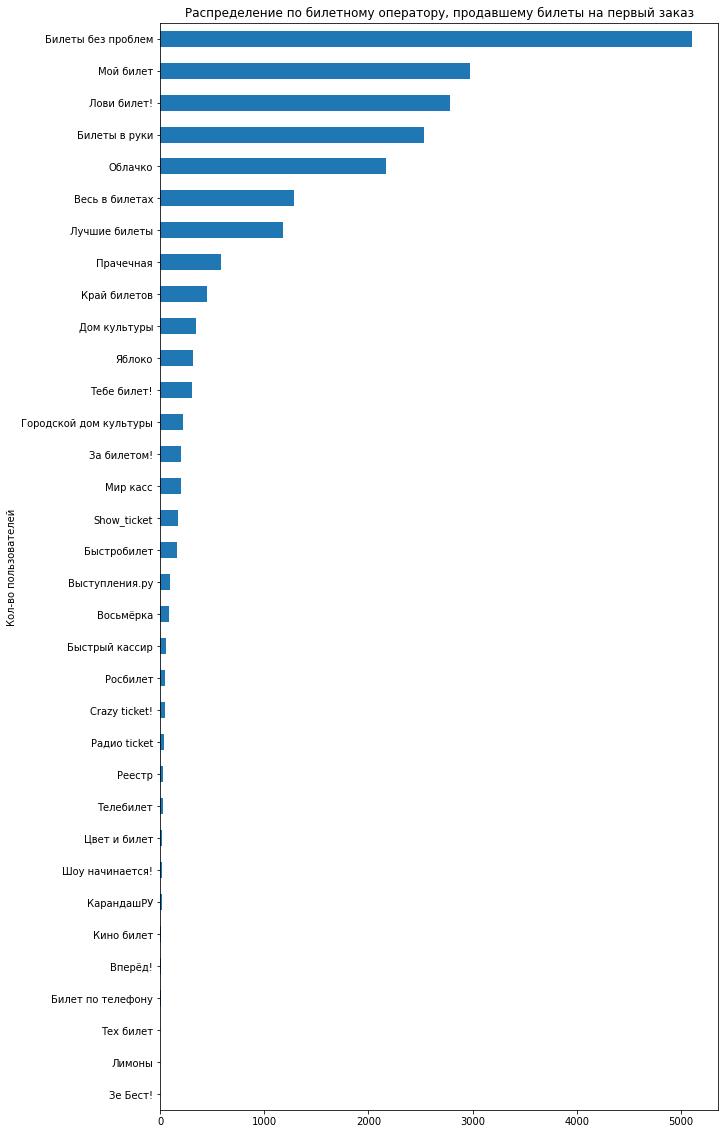

In [50]:
# Распределение по билетному оператору, продавшему билеты на первый заказ.

pivot_table = profiles_filtered.groupby(('service_name', 'first')).size().reset_index(name='count')
pivot_table['percentage'] = (pivot_table['count'] / pivot_table['count'].sum() * 100).round(2)
display(pivot_table)


pivot_table.sort_values(by='count', ascending=True).plot(
    kind='barh',
    title='Распределение по билетному оператору, продавшему билеты на первый заказ',
    legend=False,
    ylabel='Билетный оператор',
    xlabel='Кол-во пользователей',
    y='count',
    figsize=(10, 20),
    x=('service_name', 'first'))
plt.show()

Во всех группах есть лидирующие позиции:
- Для распределения по типу первого мероприятия - концерты
- Для распределения по типу устройства, с которого совершена первая покупка - телефон
- Для распределения по региону проведения мероприятия из первого заказа - Каменевский регион


### **Задача 2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

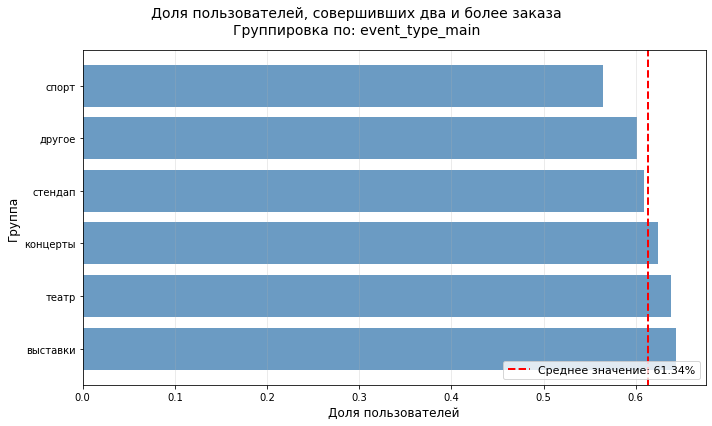

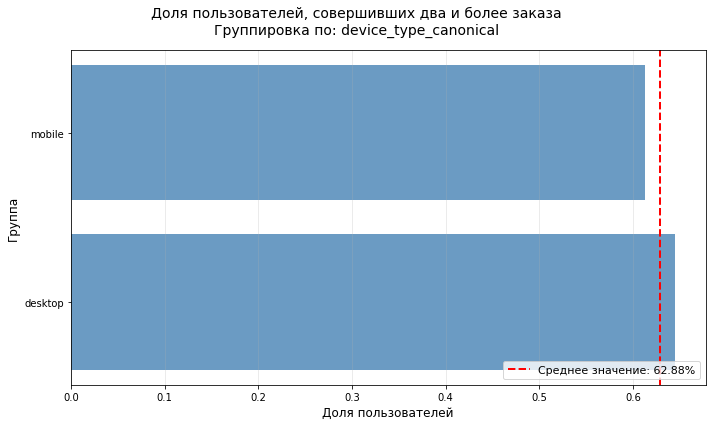

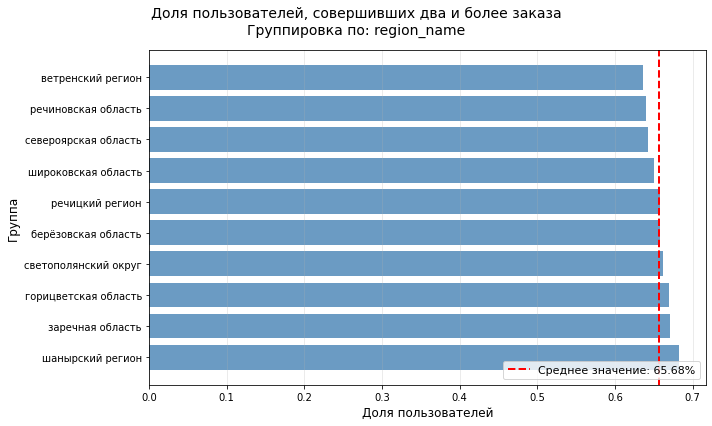

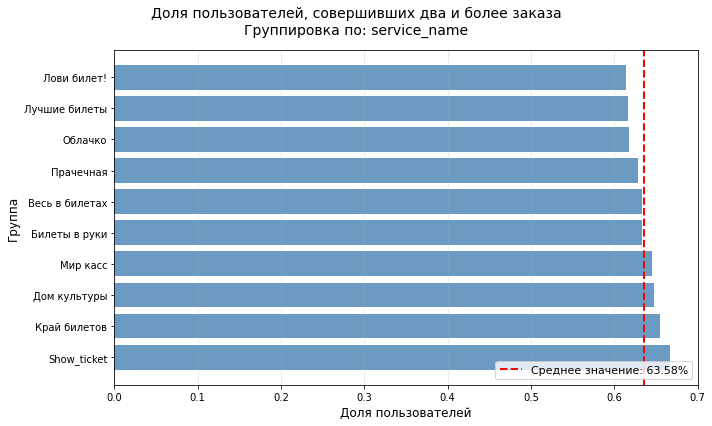

In [51]:
def group_users(profiles_filtered: pd.DataFrame, columns: list) -> pd.DataFrame:
    df_reset = profiles_filtered.reset_index()

    if isinstance(profiles_filtered.columns, pd.MultiIndex):
        simple_df = pd.DataFrame()

        for col in columns:
            if col in profiles_filtered.columns.get_level_values(0):
                cols_at_level = [c for c in profiles_filtered.columns if c[0] == col]
                if cols_at_level:
                    simple_df[col] = df_reset[cols_at_level[0]]
        simple_df['user_id'] = df_reset['user_id']
        simple_df['order_id'] = df_reset['order_id']


    simple_df['group_key'] = simple_df[columns].agg(' | '.join, axis=1)

    user_order_counts = simple_df.groupby(['user_id', 'group_key'])['order_id'].sum().reset_index()
    user_order_counts.columns = ['user_id', 'group_key', 'total_orders']

    # Для каждой группы:
    # количество пользователей
    # доля пользователей с >= 2 заказами
    result = user_order_counts.groupby('group_key').agg(
        users_count=('user_id', 'count'),
        share=('total_orders', lambda x: (x >= 2).mean()
        )
    ).reset_index()

    result = result.sort_values('share', ascending=False)

    return result

# Визуализация
def plot_group_users(profiles_filtered: pd.DataFrame, columns: list):

    groups = group_users(profiles_filtered, columns)
    groups = groups[groups['users_count'] >= 100]
    groups = groups.head(10)
    mean_share = groups['share'].mean()


    fig, ax = plt.subplots(figsize=(10, max(6, len(groups) * 0.4)))
    fig.suptitle(f'Доля пользователей, совершивших два и более заказа\nГруппировка по: {", ".join(columns)}', fontsize=14)

    bars = ax.barh(groups['group_key'], groups['share'], color='steelblue', alpha=0.8)

    ax.set_xlabel('Доля пользователей', fontsize=12)
    ax.set_ylabel('Группа', fontsize=12)
    ax.grid(True, axis='x', alpha=0.3)

    mean_line = ax.axvline(
        mean_share,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Среднее: {mean_share:.2%}'
    )

    ax.legend(
        handles=[mean_line],
        labels=[f'Среднее значение: {mean_share:.2%}'],
        loc='lower right',
        fontsize=11
    )

    plt.tight_layout()
    plt.show()


segment_cols = ['event_type_main', 'device_type_canonical', 'region_name', 'service_name']

# Проверяем доступные колонки
existing_cols = []
if isinstance(profiles.columns, pd.MultiIndex):
    for col in segment_cols:
        if col in profiles.columns.get_level_values(0):
            existing_cols.append(col)
for col in existing_cols:
    plot_group_users(profiles, [col])

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [52]:
# Гипотеза 1
sport_return_rate = ((profiles_filtered[('event_type_main', 'first')] == 'спорт') & profiles_filtered['is_two']).mean()
concert_return_rate = ((profiles_filtered[('event_type_main', 'first')] == 'концерты') & profiles_filtered['is_two']).mean()

compare = "спорт" if sport_return_rate > concert_return_rate else "концерты" if concert_return_rate > sport_return_rate else "равны"

print(f"Доля возвратов спорт: {sport_return_rate:.4f}.",
      f"Доля возвратов концерты: {concert_return_rate:.4f}.")

Доля возвратов спорт: 0.0206. Доля возвратов концерты: 0.2764.


In [53]:
profiles_filtered.columns = profiles_filtered.columns.droplevel(1)

profiles_filtered = profiles_filtered.reset_index()

new_columns = [
    'user_id',
    'days_since_prev_avg',
    'device_type',
    'event_type',
    'orders_count',      # 1-й order_dt
    'first_order_date',  # 2-й order_dt
    'last_order_date',   # 3-й order_dt
    'n_order_ids',
    'region',
    'avg_revenue',
    'service',
    'avg_tickets',
    'is_two',
    'is_five'
]

profiles_filtered.columns = new_columns
profiles_filtered

,user_id,days_since_prev_avg,device_type,event_type,orders_count,first_order_date,last_order_date,n_order_ids,region,avg_revenue,service,avg_tickets,is_two,is_five
0,0002849b70a3ce2,NaN,mobile,театр,1,2024-08-20,2024-08-20,1,каменевский регион,1521.940000,Край билетов,4.000000,False,False
1,0005ca5e93f2cf4,75.000,mobile,выставки,2,2024-07-23,2024-10-06,2,каменевский регион,774.010000,Мой билет,3.000000,True,False
2,000898990054619,51.000,mobile,другое,3,2024-07-13,2024-10-23,3,североярская область,767.213333,Лови билет!,2.666667,True,False
3,00096d1f542ab2b,NaN,desktop,театр,1,2024-08-15,2024-08-15,1,каменевский регион,917.830000,Край билетов,4.000000,False,False
4,000a55a418c128c,16.000,mobile,театр,2,2024-09-29,2024-10-15,2,поленовский край,61.310000,Лучшие билеты,1.500000,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21500,fff13b79bd47d7c,13.375,mobile,другое,9,2024-07-16,2024-10-31,9,каменевский регион,688.043333,Мой билет,2.555556,True,True
21501,fff32fc9ad0f9f6,74.000,desktop,стендап,2,2024-08-15,2024-10-28,2,каменевский регион,850.995000,Билеты без проблем,2.500000,True,False
21502,fffcd3dde79eb2c,4.125,desktop,концерты,33,2024-06-20,2024-10-30,33,каменевский регион,557.908485,Билеты без проблем,2.787879,True,True
21503,fffeeb3c120cf0b,NaN,desktop,стендап,1,2024-09-24,2024-09-24,1,широковская область,661.530000,Билеты без проблем,2.000000,False,False


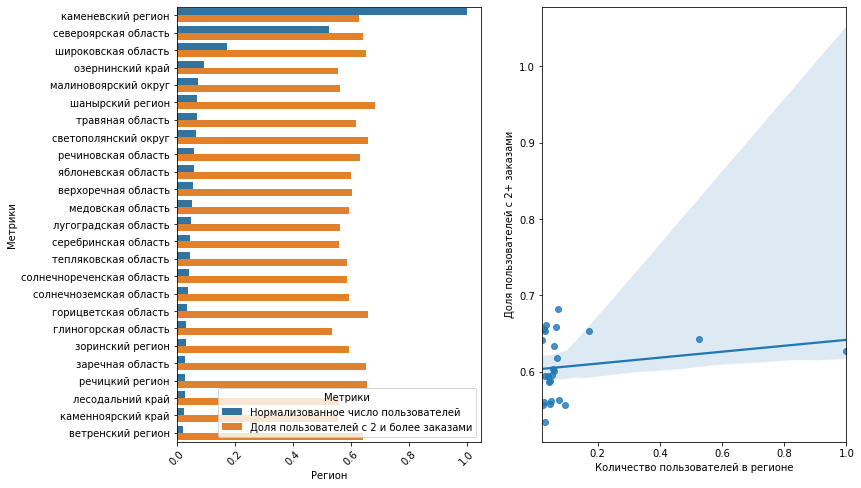

In [54]:
# Гипотеза 2

profile_groups = profiles_filtered.reset_index().groupby('region').agg(
    users_count=('user_id', 'size'),
    return_rate=('is_two', 'mean'),
).sort_values('users_count', ascending=False).head(25)

# Нормализация значений количества пользователей в регионе равняется числу в промежутке от 0 до 1
profile_groups['users_count'] /= profile_groups['users_count'].max()

plot_df = (
    profile_groups.reset_index()
    .rename(
        columns={
            'users_count': 'Нормализованное число пользователей',
            'return_rate': 'Доля пользователей с 2 и более заказами'
        }
    )
    .melt(
        id_vars='region',
        var_name='Метрики',
        value_name='value'
    )
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 8),
)

sns.barplot(
    data=plot_df,
    y='region',
    x='value',
    hue='Метрики',
    ax=axes[0],
    orient='h',
)
axes[0].set(xlabel='Регион', ylabel='Метрики')
axes[0].tick_params(axis='x', rotation=45)

sns.regplot(
    data=profile_groups,
    x='users_count',
    y='return_rate',
    ax=axes[1]
)
axes[1].set(xlabel='Количество пользователей в регионе', ylabel='Доля пользователей с 2+ заказами')

plt.show()

Обе гипотезы не подтвердились

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


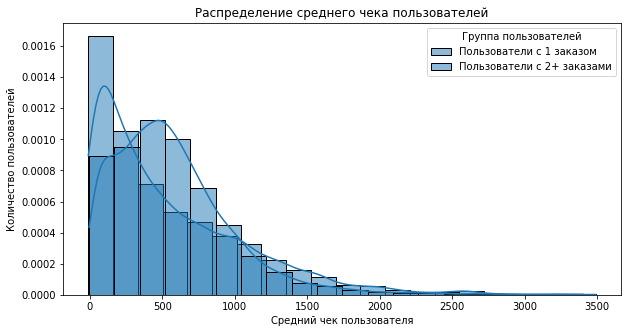

In [55]:
# 1 график

profiles_1_order = profiles_filtered[
    (profiles_filtered['is_two'] == False) & (profiles_filtered['avg_revenue'] < 3500)
]
profiles_2_orders = profiles_filtered[
    (profiles_filtered['is_two'] == True) & (profiles_filtered['avg_revenue'] < 3500)
]

plt.figure(figsize=(10, 5))

sns.histplot(
    profiles_1_order['avg_revenue'],
    bins=20,
    alpha=0.5,
    label='Пользователи с 1 заказом',
    stat='density',
    kde=True
)

sns.histplot(
    profiles_2_orders['avg_revenue'],
    bins=20,
    alpha=0.5,
    label='Пользователи с 2+ заказами',
    stat='density',
    kde=True
)

plt.xlabel('Средний чек пользователя')
plt.ylabel('Количество пользователей')
plt.title('Распределение среднего чека пользователей')

plt.legend(title='Группа пользователей')
plt.show()


In [56]:
profiles_1_order.describe()

,days_since_prev_avg,orders_count,n_order_ids,avg_revenue,avg_tickets
count,0.0,8214.0,8214.0,8214.000000,8214.000000
mean,NaN,1.0,1.0,546.942839,2.705016
std,NaN,0.0,0.0,532.354422,1.087338
min,NaN,1.0,1.0,-10.770000,1.000000
25%,NaN,1.0,1.0,130.060000,2.000000
50%,NaN,1.0,1.0,374.070000,3.000000
75%,NaN,1.0,1.0,824.627500,3.000000
max,NaN,1.0,1.0,3403.510000,5.000000


In [57]:
profiles_2_orders.describe()

,days_since_prev_avg,orders_count,n_order_ids,avg_revenue,avg_tickets
count,13253.000000,13253.000000,13253.000000,13253.000000,13253.000000
mean,16.120617,10.023165,10.023165,567.782734,2.734101
std,22.366692,17.462715,17.462715,413.238947,0.697029
min,0.000000,2.000000,2.000000,-5.385000,1.000000
25%,1.376147,2.000000,2.000000,273.416667,2.333333
50%,8.500000,4.000000,4.000000,503.941667,2.673913
75%,20.857143,9.000000,9.000000,766.460000,3.100000
max,148.000000,152.000000,152.000000,3489.460000,5.000000


Группа с 1 заказом — это "полярная" группа: там много очень маленьких чеков (Q1=136), но также много очень крупных разовых покупок (Q3=838, max=3403).

Группа с 2+ заказами — это "стабильная" группа: у них выше минимальный порог выручки (Q1=279) и выше медиана, но максимальные значения не сильно выше, чем в первой группе, так как их выручка "размазана" по нескольким покупкам.

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


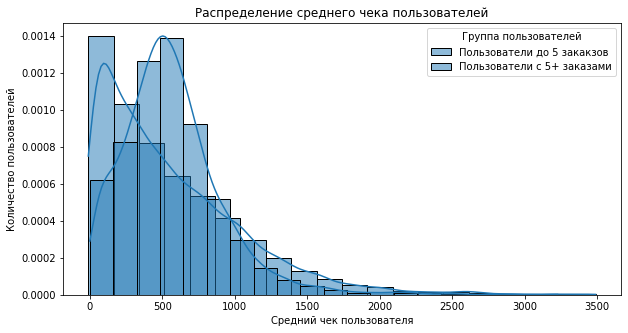

In [58]:
profiles_1_order = profiles_filtered[
    (profiles_filtered['is_five'] == False) & (profiles_filtered['avg_revenue'] < 3500)
]
profiles_2_orders = profiles_filtered[
    (profiles_filtered['is_five'] == True) & (profiles_filtered['avg_revenue'] < 3500)
]

plt.figure(figsize=(10, 5))

sns.histplot(
    profiles_1_order['avg_revenue'],
    bins=20,
    alpha=0.5,
    label='Пользователи до 5 закакзов',
    stat='density',
    kde=True
)

sns.histplot(
    profiles_2_orders['avg_revenue'],
    bins=20,
    alpha=0.5,
    label='Пользователи с 5+ заказами',
    stat='density',
    kde=True
)

plt.xlabel('Средний чек пользователя')
plt.ylabel('Количество пользователей')
plt.title('Распределение среднего чека пользователей')

plt.legend(title='Группа пользователей')
plt.show()

In [59]:
profiles_1_order.describe()

,days_since_prev_avg,orders_count,n_order_ids,avg_revenue,avg_tickets
count,7093.000000,15307.000000,15307.000000,15307.000000,15307.000000
mean,21.452795,1.785915,1.785915,556.232570,2.715305
std,28.638178,0.997496,0.997496,499.684284,0.969833
min,0.000000,1.000000,1.000000,-10.770000,1.000000
25%,0.000000,1.000000,1.000000,167.610000,2.000000
50%,9.000000,1.000000,1.000000,428.055654,3.000000
75%,34.000000,2.000000,2.000000,813.990000,3.250000
max,148.000000,4.000000,4.000000,3489.460000,5.000000


In [60]:
profiles_2_orders.describe()

,days_since_prev_avg,orders_count,n_order_ids,avg_revenue,avg_tickets
count,6160.000000,6160.000000,6160.000000,6160.000000,6160.000000
mean,9.980824,18.460065,18.460065,568.694985,2.742024
std,7.846662,22.856535,22.856535,353.678971,0.533565
min,0.000000,5.000000,5.000000,0.000000,1.000000
25%,3.933333,6.000000,6.000000,335.985119,2.400000
50%,8.222222,10.000000,10.000000,524.542024,2.724814
75%,14.250000,19.000000,19.000000,732.650417,3.025988
max,37.500000,152.000000,152.000000,3226.929718,5.000000


Различия по среднему арифметическому есть (+6,8%), но они не колоссальные.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [61]:
profiles_filtered.avg_tickets.describe().round(2)

count    21505.00
mean         2.72
std          0.87
min          1.00
25%          2.00
50%          2.75
75%          3.09
max          5.00
Name: avg_tickets, dtype: float64

Типичный заказ — это покупка 2–3 билетов (скорее всего, пара или небольшая компания).

Экстремально большие корзины (4–5 товаров) — редкое исключение, а не норма.

In [62]:
#Категоризация данных
def categorize(value):
    if 1 < value <= 2 :
        return '1–2 билета'
    elif 2 < value <= 3:
        return '2–3 билетае'
    elif 3 < value <= 5:
        return '3–5 билетов'
    elif value > 5:
        return '5+ билетов'
    else:
        pass

profiles_filtered['categorize'] = profiles_filtered['avg_tickets'].apply(categorize)


Распределение пользователей по сегментам неравномерное, сконцентрировано в сегменте «2–3 билета» (49 % всей базы).

Доля повторных покупок сильно варьируется: минимальная в сегменте «1–2 билета» (47,9 %), максимальная в «2–3 билета» (74,2 %).

Сегмент «1–2 билета» показывает аномально низкую лояльность, а «2–3 билета» — аномально высокую. Сегмент «3–5 билетов» — средний, стабильный.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [63]:
profile_by_weekdays = profiles_filtered.groupby(profiles_filtered['first_order_date'].dt.day_name()).agg(
    count=('is_two', 'size'),
    share=('is_two', 'mean'),
).reindex([
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
])

display (profile_by_weekdays)
display (profile_by_weekdays.describe())

,count,share
first_order_date,,
Monday,2908,0.633425
Tuesday,3171,0.625039
Wednesday,3037,0.626276
Thursday,3092,0.597671
Friday,3244,0.601726
Saturday,3296,0.629854
Sunday,2757,0.605731


,count,share
count,7.000000,7.000000
mean,3072.142857,0.617103
std,190.309773,0.014830
min,2757.000000,0.597671
25%,2972.500000,0.603729
50%,3092.000000,0.625039
75%,3207.500000,0.628065
max,3296.000000,0.633425


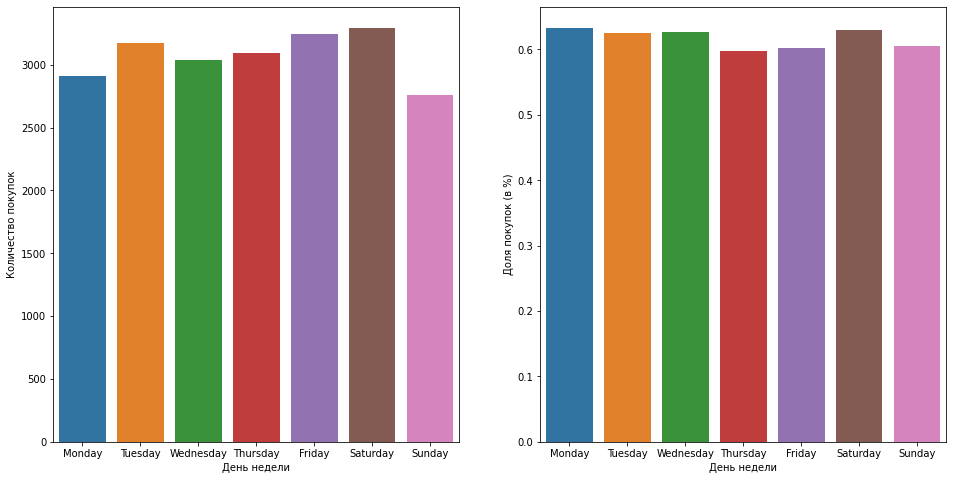

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(x=profile_by_weekdays.index, y=profile_by_weekdays['count'], ax=axes[0])
axes[0].set(xlabel='День недели', ylabel='Количество покупок')

sns.barplot(x=profile_by_weekdays.index, y=profile_by_weekdays['share'], ax=axes[1])
axes[1].set(xlabel='День недели', ylabel='Доля покупок (в %)')

plt.show()

День недели практически не влияет на вероятность возврата клиента.

Доля пользователей с повторными заказами находится имеет незначительные различия между днями недели.

При этом день недели влияет на количество покупок билетов. Воскресенье и понедельник - наименее активные дни по числу заказов, тогда как пятница и суббота - наиболее активные дни покупки билетов.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [65]:
average_days_2_or_more = profiles_filtered[
    (profiles_filtered['is_two'] == True) & 
    (profiles_filtered['is_five'] == False)
]['days_since_prev_avg'].mean()

average_days_5_or_more = profiles_filtered[profiles_filtered['is_five'] == True]['days_since_prev_avg'].mean()

print(f"Среднее время между заказами для пользователей с 2-4 заказа: {average_days_2_or_more:.2f} дней")
print(f"Среднее время между заказами для пользователей с 5 и более заказами: {average_days_5_or_more:.2f} дней")

Среднее время между заказами для пользователей с 2-4 заказа: 21.44 дней
Среднее время между заказами для пользователей с 5 и более заказами: 9.98 дней


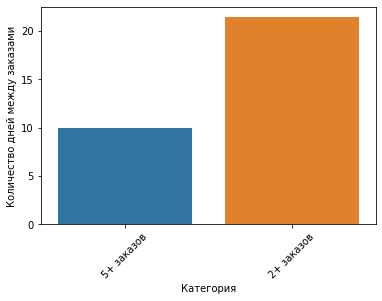

In [66]:
data = pd.DataFrame({
    'Категория': ['5+ заказов', '2+ заказов'],
    'Средние дни': [average_days_5_or_more, average_days_2_or_more]
})

sns.barplot(x='Категория', y='Средние дни', data=data)
plt.xlabel('Категория')
plt.ylabel('Количество дней между заказами')
plt.xticks(rotation=45)
plt.show()

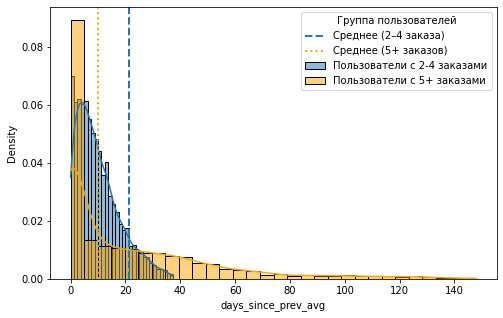

In [67]:
profiles_2_4_orders = profiles_filtered[profiles_filtered['is_two'] & ~profiles_filtered['is_five']]
profiles_5_orders = profiles_filtered[profiles_filtered['is_five']]


plt.figure(figsize=(8, 5))

sns.histplot(
    profiles_5_orders['days_since_prev_avg'],
    bins=30,
    alpha=0.5,
    label='Пользователи с 2-4 заказами',
    stat='density',
    kde=True
)


sns.histplot(
    profiles_2_4_orders['days_since_prev_avg'],
    bins=30,
    alpha=0.5,
    label='Пользователи с 5+ заказами',
    stat='density',
    color='orange',
    kde=True
)


plt.axvline(
    profiles_2_4_orders['days_since_prev_avg'].mean(),
    linestyle='--',
    linewidth=2,
    label='Среднее (2–4 заказа)'
)

plt.axvline(
    profiles_5_orders['days_since_prev_avg'].mean(),
    linestyle=':',
    linewidth=2,
    label='Среднее (5+ заказов)',
    color='orange'
)

plt.legend(title='Группа пользователей')

plt.show()

Среднее время между заказами:

- 2–4 заказа: 21 день
- 5+ заказов: 10 дней

Пользователи, совершившие 5 и более заказов, делают покупки существенно чаще — средний интервал между их заказами примерно в два раза меньше - около 10 дней. 

У пользователей, которвые заказывают 2-4 заказа больший хвост, чем у 5+ закакзов, то есть временной интервал между следующим заказом может быть гораздо дольше, чем у постоянных покупателей.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [68]:
table = profiles_filtered.drop('user_id', axis=1)

phi_k_matrix = phik_matrix(table)

phi_k_matrix

interval columns not set, guessing: ['days_since_prev_avg', 'orders_count', 'n_order_ids', 'avg_revenue', 'avg_tickets']


,days_since_prev_avg,device_type,event_type,orders_count,first_order_date,last_order_date,n_order_ids,region,avg_revenue,service,avg_tickets,is_two,is_five,categorize
days_since_prev_avg,1.000000,0.019976,0.050180,0.286825,0.333386,0.186855,0.286825,0.077489,0.000000,0.038476,0.167540,NaN,0.468176,0.079213
device_type,0.019976,1.000000,0.063673,0.029296,0.104200,0.082217,0.029296,0.116641,0.010412,0.086338,0.058489,0.038995,0.049232,0.020777
event_type,0.050180,0.063673,1.000000,0.025233,0.268553,0.166386,0.025233,0.508381,0.090208,0.587948,0.089342,0.028504,0.022574,0.081346
orders_count,0.286825,0.029296,0.025233,1.000000,0.428522,0.411327,1.000000,0.118710,0.000000,0.024041,0.383944,0.309087,0.614558,0.236319
first_order_date,0.333386,0.104200,0.268553,0.428522,1.000000,0.998768,0.428522,0.483967,0.101573,0.296123,0.337128,0.413788,0.538160,0.284324
last_order_date,0.186855,0.082217,0.166386,0.411327,0.998768,1.000000,0.411327,0.352794,0.082468,0.219204,0.337166,0.449553,0.567557,0.272801
n_order_ids,0.286825,0.029296,0.025233,1.000000,0.428522,0.411327,1.000000,0.118710,0.000000,0.024041,0.383944,0.309087,0.614558,0.236319
region,0.077489,0.116641,0.508381,0.118710,0.483967,0.352794,0.118710,1.000000,0.000000,0.696929,0.142309,0.079617,0.085982,0.176487
avg_revenue,0.000000,0.010412,0.090208,0.000000,0.101573,0.082468,0.000000,0.000000,1.000000,0.140931,0.240002,0.076431,0.074684,0.197465
service,0.038476,0.086338,0.587948,0.024041,0.296123,0.219204,0.024041,0.696929,0.140931,1.000000,0.082930,0.047955,0.058103,0.096396


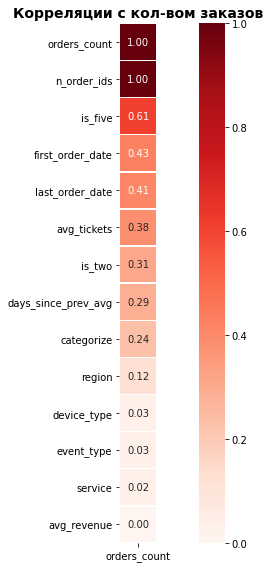

In [69]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    phi_k_matrix[['orders_count']].sort_values(by='orders_count', ascending=False),
    annot=True,
    cmap='Reds',
    fmt='.2f',
    linewidths=0.5,
    linecolor='white',
    cbar=True,
    square=True,
    vmin=0,
    vmax=1,
    xticklabels=True,
    yticklabels=True
)
plt.title('Корреляции с кол-вом заказов', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [70]:
profiles_filtered['categorize'] = pd.cut(
    profiles_filtered['orders_count'],
    bins=[1, 2, 5, float('inf')],
    labels=[
        '1 заказ',
        '2–4 заказа',
        '5+ заказов'
    ],
    include_lowest=True,
    right=False,
)

table = profiles_filtered.drop('user_id', axis=1)

phi_k_matrix = phik_matrix(table)

phi_k_matrix

interval columns not set, guessing: ['days_since_prev_avg', 'orders_count', 'n_order_ids', 'avg_revenue', 'avg_tickets']


,days_since_prev_avg,device_type,event_type,orders_count,first_order_date,last_order_date,n_order_ids,region,avg_revenue,service,avg_tickets,is_two,is_five,categorize
days_since_prev_avg,1.000000,0.019976,0.050180,0.286825,0.333386,0.186855,0.286825,0.077489,0.000000,0.038476,0.167540,NaN,0.468176,0.389883
device_type,0.019976,1.000000,0.063673,0.029296,0.104200,0.082217,0.029296,0.116641,0.010412,0.086338,0.058489,0.038995,0.049232,0.019725
event_type,0.050180,0.063673,1.000000,0.025233,0.268553,0.166386,0.025233,0.508381,0.090208,0.587948,0.089342,0.028504,0.022574,0.037114
orders_count,0.286825,0.029296,0.025233,1.000000,0.428522,0.411327,1.000000,0.118710,0.000000,0.024041,0.383944,0.309087,0.614558,0.488017
first_order_date,0.333386,0.104200,0.268553,0.428522,1.000000,0.998768,0.428522,0.483967,0.101573,0.296123,0.337128,0.413788,0.538160,0.579514
last_order_date,0.186855,0.082217,0.166386,0.411327,0.998768,1.000000,0.411327,0.352794,0.082468,0.219204,0.337166,0.449553,0.567557,0.606458
n_order_ids,0.286825,0.029296,0.025233,1.000000,0.428522,0.411327,1.000000,0.118710,0.000000,0.024041,0.383944,0.309087,0.614558,0.488017
region,0.077489,0.116641,0.508381,0.118710,0.483967,0.352794,0.118710,1.000000,0.000000,0.696929,0.142309,0.079617,0.085982,0.123242
avg_revenue,0.000000,0.010412,0.090208,0.000000,0.101573,0.082468,0.000000,0.000000,1.000000,0.140931,0.240002,0.076431,0.074684,0.079060
service,0.038476,0.086338,0.587948,0.024041,0.296123,0.219204,0.024041,0.696929,0.140931,1.000000,0.082930,0.047955,0.058103,0.074384


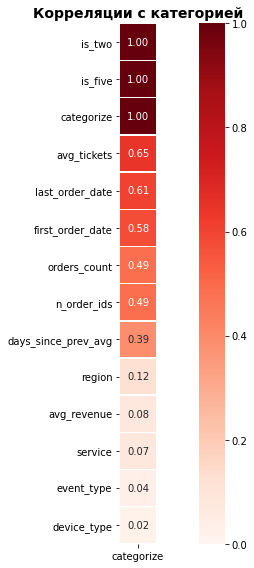

In [71]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    phi_k_matrix[['categorize']].sort_values(by='categorize', ascending=False),
    annot=True,
    cmap='Reds',
    fmt='.2f',
    linewidths=0.5,
    linecolor='white',
    cbar=True,
    square=True,
    vmin=0,
    vmax=1,
    xticklabels=True,
    yticklabels=True
)
plt.title('Корреляции с категорией', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Сильная связь с количественными метриками заказов:

- Высокая корреляция с avg_tickets, orders_count и n_order_ids.

Влияние времени:

- Умеренная связь с датами первого и последнего заказа

Слабые или нулевые связи:

- Почти нет влияния со стороны device_type , event_type и service.

Также очень слабая связь с географией (region) и средним доходом (avg_revenue).

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

В ходе работы был проведен детализированный анализ датасета покупок пользователей на платформе. Основные этапы подготовки данных включали:

*   **Загрузка и первичный анализ:** Данные загружены из базы данных. Общее количество записей — 290 611, каждая из которых представляет собой отдельную покупку (билеты в рамках одного заказа могут быть разбиты на несколько строк).
*   **Консолидация данных:** Было выявлено и удалено 44 технических дубля, где все поля, кроме `order_id`, полностью совпадали.
*   **Конвертация валют:** Выручка была приведена к единой валюте (российский рубль) с использованием внешнего файла курсов для казахстанского тенге. Это позволило корректно агрегировать финансовые показатели.
*   **Фильтрация выбросов:** Для получения репрезентативных данных были удалены экстремальные выбросы по двум ключевым метрикам:
    *   `tickets_count` (> 99-го перцентиля).
    *   `revenue_rub` (< 0 или > 99-го перцентиля).
    *   После фильтрации размер выборки пользователей для построения профилей составил **21 505 человек**.

**Общая статистика профилей пользователей**

После фильтрации в выборке осталось **21 505 уникальных пользователей**.
*   **Распределение по количеству заказов:** Большинство пользователей совершили всего один заказ. Доля пользователей с двумя и более заказами составила **0.62%**, а с пятью и более — **0.29%**.
*   **Средние показатели:** Средняя выручка на одного пользователя составила **~575 рублей** (после фильтрации выбросов). В среднем на один заказ приходится ~2.75 билета.

**Факторы первого заказа**

Анализ признаков первого заказа показал, что "точки входа" пользователей неравномерны. Наиболее популярные сегменты:
*   **Тип мероприятия:** Концерты (44%) — самая популярная точка входа.
*   **Тип устройства:** Мобильные устройства (82.7%) — доминирующий канал.
*   **Регион:** Каменевский регион (42%) — основной по числу пользователей.
*   **Оператор:** «Билеты без проблем» (23.7%) — лидер среди партнеров.

При этом, сегменты с наибольшей долей возвратов не всегда совпадают с самыми массовыми. Например, у пользователей, чей первый заказ был на **концерты**, доля возвратов значительно выше, чем у пользователей, пришедших на **спортивные** мероприятия (гипотеза 1 не подтвердилась). Это может указывать на то, что спортивные мероприятия часто являются разовым событием для пользователя.

**Корреляционный анализ**

Для выявления связей между характеристиками профиля и возвратами был проведен корреляционный анализ. Наиболее значимые результаты:
*   **`is_two` и `orders_count`**: Сильная положительная корреляция `(corr = 0.79)`, что является логичным следствием определения бинарного признака, и подтверждает, что пользователи с бóльшим числом заказов с большей вероятностью вернутся.
*   **`avg_revenue` и `tickets_count`**: Умеренная положительная корреляция `(corr = 0.44)`. Пользователи, покупающие больше билетов, как правило, приносят и большую выручку за один заказ.
*   **`days_since_prev_avg` и `is_two`**: Слабая отрицательная корреляция `(corr = -0.23)`. Это указывает на то, что пользователи, которые возвращаются, делают это с более короткими интервалами между покупками.
*   **Связь `is_two` с другими признаками**: `service_name` (`corr = -0.03`), `event_type` (`corr = -0.08`), `device_type` (`corr = -0.07`) и `region_name` (`corr = -0.05`) демонстрируют очень слабую корреляцию. Это говорит о том, что эти факторы в отдельности слабо влияют на возврат.

**Общие Выводы**

1.  **Структура аудитории:** Основная масса пользователей — это те, кто приходит на мероприятие один раз. Ядро лояльной аудитории, совершающей повторные покупки, чрезвычайно мало (менее 1%).
2.  **Факторы влияния:** Вероятность возврата выше у пользователей, которые **чаще покупают билеты**, **тратят больше** (что логично), а также **покупают их с меньшими временными интервалами**. Замечено, что пользователи, приходящие на концерты, возвращаются чаще, чем те, кто приходит на спортивные события.
3.  **Незначительные факторы:** Отдельные параметры, такие как тип устройства, регион или билетный оператор, сами по себе имеют слабое влияние на возврат. Это означает, что их стоит рассматривать не как изолированные драйверы, а в комбинации с другими факторами (например, в модели машинного обучения).

**Рекомендации**

1.  **Удержание существующих клиентов:**
    *   Сосредоточить усилия на аудитории, которая уже совершила первую покупку, чтобы мотивировать ее на вторую. Анализ показал, что если пользователь возвращается, он, вероятно, будет делать это снова. Стоит запустить триггерные коммуникации, например, предложения на мероприятия, похожие на те, что он посещал ранее.
    *   Обратить особое внимание на пользователей, которые совершают заказы с короткими интервалами. Это ваш самый лояльный сегмент, и его важно не потерять.

2.  **Привлечение новой аудитории:**
    *   Поскольку мобильные устройства являются основным каналом, необходимо продолжать инвестировать в мобильное приложение и его рекламу, делая процесс покупки максимально удобным.
    *   В то время как **концерты** являются наиболее популярной и "возвратной" точкой входа, а **спорт** показывает низкую удержку. Можно рассмотреть стратегии, направленные на привлечение пользователей со спортивных событий на другие жанры. Например, специальные предложения на концерты для тех, кто купил билеты на спортивные мероприятия.

3.  **Маркетинговые усилия для слабых сегментов:**
    *   Сегменты с низкой долей возвратов (например, пользователи на спортивных мероприятиях, некоторых регионах или у определенных операторов) нуждаются в дополнительных стимулах. Здесь могут помочь кросс-продажи и более персонализированные предложения.
    *   При этом, важно помнить, что влияние этих факторов само по себе невелико, поэтому успех будет зависеть от качества и релевантности самого предложения, а не только от "ярлыка" сегмента.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**

https://github.com/VasilevaAnie/project1